# Baseline Benchmark

This notebook establishes a benchmark for all subsequent recommendation models. Every model is evaluated using the same train/test split and evaluation protocol defined in Notebook 02, ensuring a fair comparison throughout the project.

All of these are **retrieval** models — they find relevant games for a user. Only the representation changes across the project (popularity → multi-hot space → semantic space → learned space).

## Бенчмарк базовых моделей

Этот ноутбук задаёт эталон для всех последующих рекомендательных моделей. Каждая модель оценивается на одном и том же train/test split и протоколе оценки из Ноутбука 02, что обеспечивает честное сравнение на протяжении всего проекта.

Все они — **retrieval**-модели: ищут релевантные игры для пользователя. По ходу проекта меняется только представление объектов (популярность → multi-hot пространство → семантическое → обученное).

In [2]:
import os
# Single-threaded BLAS (set before numpy import) to avoid the implicit MKL warning
# Однопоточный BLAS (до импорта numpy), чтобы убрать MKL-warning из implicit
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Project root directory
# Корневая директория проекта
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"

# Make src importable and load models + evaluation harness
# Делаем src импортируемым и подключаем модели + harness оценки
sys.path.insert(0, str(ROOT))
from src.baselines import PopularityRecommender, ContentBasedRecommender, ALSRecommender
from src.evaluation import evaluate

# Plot style
# Стиль графиков
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("ready")

ready


/home/mchunikhin/miniconda3/envs/rapids/lib/python3.11/site-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of 'libcublas.so.13: cannot open shared object file: No such file or directory'
  warnings.warn(


## Load Data

We load the train/test split, the game metadata, and the split metadata produced by the validation notebook.

## Загрузка данных

Загружаем train/test split, метаданные игр и метаданные split из ноутбука валидации.

In [3]:
# Load the frozen split and game features
# Загружаем зафиксированный split и признаки игр
train = pd.read_parquet(DATA / "processed" / "train.parquet")
test = pd.read_parquet(DATA / "processed" / "test.parquet")
games = pd.read_parquet(DATA / "processed" / "games.parquet")

with open(DATA / "processed" / "split_metadata.json") as f:
    split_meta = json.load(f)

print("train:", train.shape, "| test:", test.shape, "| games:", games.shape)
print("split:", split_meta["strategy"], "| train_size:", f"{split_meta['train_size']:,}",
      "| test_size:", f"{split_meta['test_size']:,}")

train: (787585, 5) | test: (113552, 5) | games: (2759, 12)
split: leave_last_out | train_size: 787,585 | test_size: 113,552


## Evaluation Framework

Every model is judged the same way before we train a single one.

- **Ground truth**: each user's held-out last interaction (one game per user, leave-last-out).
- **Top-K recommendation**: each model returns up to K games per user, excluding games already seen in train.
- **Metrics** at K = 10: Recall@10, MAP@10, NDCG@10.

Because each user has exactly one held-out interaction, Recall@10 is equivalent to HitRate@10, while MAP@10 and NDCG@10 additionally reward placing the relevant game at a higher rank.

The harness is model-agnostic: `evaluate(model, train, test, k)` works for any model implementing `fit` and `recommend`.

## Протокол оценки

Каждую модель оцениваем одинаково ещё до обучения.

- **Ground truth**: отложенное последнее взаимодействие юзера (одна игра на юзера, leave-last-out).
- **Top-K рекомендации**: модель возвращает до K игр на юзера, исключая уже виденные в train.
- **Метрики** при K = 10: Recall@10, MAP@10, NDCG@10.

Так как у каждого юзера ровно одно отложенное взаимодействие, Recall@10 эквивалентен HitRate@10, а MAP@10 и NDCG@10 дополнительно вознаграждают более высокую позицию релевантной игры в ранжировании.

Harness не зависит от модели: `evaluate(model, train, test, k)` работает с любой моделью, реализующей `fit` и `recommend`.

In [4]:
# Collect results here for the final comparison
# Собираем результаты сюда для финального сравнения
K = 10
results = {}

## Popularity Baseline

The simplest possible model: recommend the globally most popular games (by interaction count), skipping what the user already played. It has no notion of a vector space, but it is a strong baseline on skewed catalogs.

## Базовая модель: популярность

Самая простая модель: рекомендуем глобально самые популярные игры (по числу взаимодействий), пропуская уже сыгранные. У неё нет векторного пространства, но на перекошенных каталогах это сильный baseline.

In [5]:
# Popularity baseline
# Базовая модель популярности
pop = PopularityRecommender().fit(train)
results["Popularity"] = evaluate(pop, train, test, k=K)
print(results["Popularity"])

{'Recall@10': 0.12241087783570523, 'MAP@10': 0.04073433386787621, 'NDCG@10': 0.059478499348514104}


## Genre/Tag Content-Based

Vector-space retrieval based on structured game metadata. Games are represented as weighted multi-hot vectors built from genres and tags, with genres weighted (`W = 2`) because genres represent broad game categories while tags capture finer semantic details. A user profile is the L2-normalized mean of their games' vectors, and games are ranked by cosine similarity in this space.

No NLP here — review text and transformers are intentionally left for the next notebook, so the gain from semantic representations is measurable.

## Content-Based по жанрам и тегам

Vector-space retrieval на структурированных метаданных игр. Каждая игра представлена взвешенным multi-hot вектором из жанров и тегов, жанры с весом (`W = 2`), потому что жанры — это широкие категории, а теги — более тонкие семантические детали. Профиль юзера — L2-нормированное среднее векторов его игр, игры ранжируются по cosine в этом пространстве.

NLP здесь нет — текст отзывов и трансформеры намеренно оставлены следующему ноутбуку, чтобы прирост от семантических представлений был измеримым.

In [6]:
# Genre/Tag content-based baseline
# Базовая content-based модель по жанрам и тегам
cb = ContentBasedRecommender(games, genre_weight=2).fit(train)
results["Genre/Tag Content-Based"] = evaluate(cb, train, test, k=K)
print(results["Genre/Tag Content-Based"])

{'Recall@10': 0.047088558545864447, 'MAP@10': 0.019020476039506965, 'NDCG@10': 0.025537468710750213}


## ALS

Collaborative filtering with implicit ALS. Unlike the previous models, ALS learns latent user and item factors purely from the co-occurrence of user behaviour, without any content features.

BM25 weighting is applied before matrix factorization to better model implicit-feedback interactions (down-weighting very active users and very popular games). We use binary feedback (interaction = 1, no playtime weighting) and a single tuning step (`factors=128`, `iterations=25`).

## ALS

Коллаборативная фильтрация: implicit ALS. В отличие от предыдущих моделей, ALS обучает латентные факторы пользователей и игр только из совместного поведения, без контентных признаков.

Перед матричной факторизацией применяется BM25-взвешивание, чтобы лучше моделировать implicit-feedback взаимодействия (приглушает слишком активных юзеров и слишком популярные игры). Используем бинарный feedback (взаимодействие = 1, без весов по playtime) и один шаг тюнинга (`factors=128`, `iterations=25`).

In [7]:
# ALS baseline (BM25-weighted, single tuning step)
# Базовая модель ALS (BM25-взвешивание, один шаг тюнинга)
als = ALSRecommender(factors=128, iterations=25, regularization=0.05).fit(train)
results["ALS"] = evaluate(als, train, test, k=K)
print(results["ALS"])

{'Recall@10': 0.13431731717627166, 'MAP@10': 0.05944343588616696, 'NDCG@10': 0.07693395713545903}


## Baseline Comparison

The benchmark: all classical retrieval models side by side on the same protocol.

## Сравнение базовых моделей

Бенчмарк: все классические retrieval-модели рядом на одном протоколе.

                         Recall@10  MAP@10  NDCG@10
Popularity                  0.1224  0.0407   0.0595
Genre/Tag Content-Based     0.0471  0.0190   0.0255
ALS                         0.1343  0.0594   0.0769


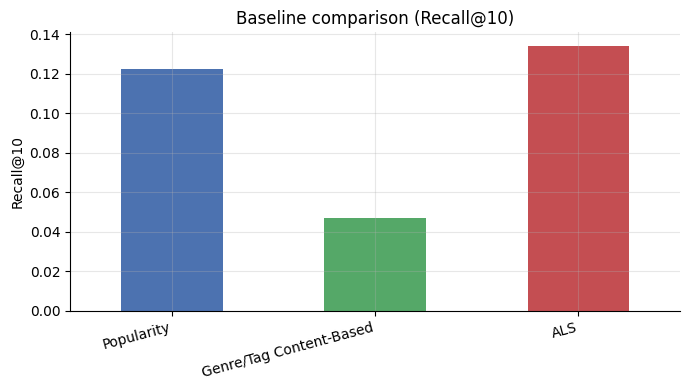

In [8]:
# Comparison table
# Таблица сравнения
benchmark = pd.DataFrame(results).T[[f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}"]]
benchmark = benchmark.round(4)
print(benchmark.to_string())

# Bar chart of Recall@10
# Столбчатый график Recall@10
fig, ax = plt.subplots(figsize=(7, 4))
benchmark[f"Recall@{K}"].plot.bar(ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel(f"Recall@{K}")
ax.set_title(f"Baseline comparison (Recall@{K})")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Discussion

**Popularity.** Despite its simplicity, the popularity baseline provides a surprisingly strong reference on this dataset, due to the temporal evaluation protocol and the popularity bias of recent Steam interactions.

**Content-Based.** Using only structured metadata limits the ability to capture collaborative user preferences, which results in lower recommendation quality.

**ALS.** After a single round of engineering improvements (BM25 weighting and moderate hyperparameter tuning), ALS becomes the strongest classical baseline and establishes the benchmark for the following stages of the project.

## Обсуждение

**Популярность.** Несмотря на простоту, popularity baseline даёт неожиданно сильную точку отсчёта на этих данных — из-за temporal-протокола оценки и смещения к популярным свежим играм Steam.

**Content-Based.** Опора только на структурированные метаданные ограничивает способность улавливать коллаборативные предпочтения пользователей, что даёт более низкое качество рекомендаций.

**ALS.** После одного раунда инженерных улучшений (BM25-взвешивание и умеренный тюнинг гиперпараметров) ALS становится сильнейшим классическим baseline и задаёт эталон для следующих этапов проекта.

## Benchmark Summary

Best model per stage — this table grows as the project progresses.

| Stage | Best Model |
|---|---|
| Classical Retrieval | ALS |

## Сводка бенчмарка

Лучшая модель на каждом этапе — таблица расширяется по мере развития проекта.

| Этап | Лучшая модель |
|---|---|
| Classical Retrieval | ALS |

## Next Step

The next stage replaces manually engineered metadata representations with semantic representations learned from review text using Sentence Transformers. The resulting semantic content-based retrieval model is evaluated against this benchmark on the exact same protocol.

## Следующий этап

Следующий этап заменяет вручную сконструированные представления из метаданных на семантические представления, выученные из текста отзывов с помощью Sentence Transformers. Получившаяся семантическая content-based retrieval-модель оценивается против этого бенчмарка на том же самом протоколе.